In [2]:
# =========================================================
# 1. SETUP
# =========================================================

!pip install pandas numpy scikit-learn matplotlib seaborn nltk joblib

import os
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [3]:
# =========================================================
# 2. GOOGLE DRIVE SETUP
# =========================================================

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/nlp_project"
DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

for d in [DATA_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

Mounted at /content/drive


In [4]:
# =========================================================
# 3. LOAD DATA FROM ZIP & SAMPLE 200k ROWS
# =========================================================

import pandas as pd

# Path to the zipped CSV file (adjust if needed)
zip_path = f"{DATA_DIR}/AI_Human.csv.zip"

# Read directly from zip – pandas handles it automatically
df = pd.read_csv(zip_path, compression='zip')

# Drop missing/duplicates
df = df.dropna(subset=['text'])
df = df.drop_duplicates()

# Sample 200,000 rows for faster processing
df = df.sample(n=200000, random_state=42).reset_index(drop=True)

print("Dataset shape after sampling:", df.shape)

Dataset shape after sampling: (200000, 2)


In [5]:
# Dataset statistics
print("Class distribution:")
print(df['generated'].value_counts())
print()
print("Text length statistics (characters):")
print(df['text'].apply(len).describe())

Class distribution:
generated
0.0    125349
1.0     74651
Name: count, dtype: int64

Text length statistics (characters):
count    200000.000000
mean       2270.173975
std         986.899988
min           1.000000
25%        1585.000000
50%        2103.000000
75%        2722.000000
max       11641.000000
Name: text, dtype: float64


In [ ]:
df['generated'].value_counts()

,count
generated,
0.0,125349
1.0,74651


In [6]:
# =========================================================
# 4. FAST PREPROCESSING (Parallel)
# =========================================================

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from joblib import Parallel, delayed
import numpy as np

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

CONFIG = {
    "remove_stopwords": True,
    "lemmatize": True          # Set to False to make it even faster
}

def preprocess_batch(texts, config):
    """Process a list of texts and return cleaned strings."""
    results = []
    for text in texts:
        # Lowercase and tokenize
        tokens = word_tokenize(text.lower())
        # Keep only alphabetic tokens (remove numbers/punctuation)
        tokens = [t for t in tokens if t.isalpha()]

        if config["remove_stopwords"]:
            tokens = [t for t in tokens if t not in stop_words]

        if config["lemmatize"]:
            tokens = [lemmatizer.lemmatize(t) for t in tokens]

        results.append(" ".join(tokens))
    return results

print("Preprocessing in parallel (8 chunks)...")
texts = df["text"].tolist()

# Split into 8 chunks
chunk_size = len(texts) // 8
chunks = [texts[i:i+chunk_size] for i in range(0, len(texts), chunk_size)]

# Process chunks in parallel
processed_chunks = Parallel(n_jobs=-1, verbose=10)(
    delayed(preprocess_batch)(chunk, CONFIG) for chunk in chunks
)

# Flatten results
df["clean_text"] = [item for sublist in processed_chunks for item in sublist]

print("Preprocessing done.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Preprocessing in parallel (8 chunks)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done   6 out of   8 | elapsed:  6.9min remaining:  2.3min


Preprocessing done.


[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:  9.1min finished


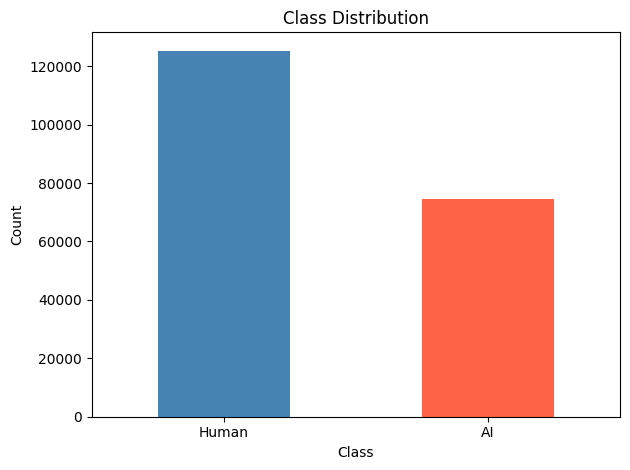

In [8]:
df['generated'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution')
plt.xticks([0,1], ['Human','AI'], rotation=0)
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('lass_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =========================================================
# 5. FEATURE EXTRACTION
# =========================================================

TFIDF_PATH = f"{DATA_DIR}/tfidf.pkl"

if os.path.exists(TFIDF_PATH):
    print("Loading TF-IDF...")
    tfidf = joblib.load(TFIDF_PATH)
    X = tfidf.transform(df["clean_text"])
else:
    print("Creating TF-IDF...")
    tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2))
    X = tfidf.fit_transform(df["clean_text"])
    joblib.dump(tfidf, TFIDF_PATH)

y = df["generated"]

Creating TF-IDF...


In [ ]:
# =========================================================
# 6. TRAIN TEST SPLIT (WITH INDEX TRACKING)
# =========================================================

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)


In [ ]:
# =========================================================
# 7. MODEL CHECKPOINTING
# =========================================================

def get_model_path(name):
    return os.path.join(MODEL_DIR, f"{name}.pkl")

def save_model(model, name):
    joblib.dump(model, get_model_path(name))
    print(f"Saved {name}")

def load_model(name):
    path = get_model_path(name)
    if os.path.exists(path):
        print(f"Loading {name}")
        return joblib.load(path)
    return None


In [ ]:
# =========================================================
# 8. MODELS (OPTIMIZED)
# =========================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}


In [ ]:
# =========================================================
# 9. TRAINING + AUTO-RESUME
# =========================================================

results = []
predictions_store = {}

for name, model in models.items():
    print(f"\nProcessing {name}")

    existing = load_model(name)

    if existing is not None:
        model = existing
    else:
        print("Training...")
        start = time.time()
        model.fit(X_train, y_train)
        print(f"Training time: {time.time() - start:.2f}s")
        save_model(model, name)

    y_pred = model.predict(X_test)
    predictions_store[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append([name, acc, prec, rec, f1])

    print(f"F1: {f1:.4f}")


Processing Logistic Regression
Training...
Training time: 1.98s
Saved Logistic Regression
F1: 0.9821

Processing Naive Bayes
Training...
Training time: 0.10s
Saved Naive Bayes
F1: 0.9109

Processing SVM
Training...
Training time: 3.47s
Saved SVM
F1: 0.9880

Processing Random Forest
Training...
Training time: 280.33s
Saved Random Forest
F1: 0.9951

Processing Gradient Boosting
Training...
Training time: 979.31s
Saved Gradient Boosting
F1: 0.9458


In [ ]:
# =========================================================
# 10. RESULTS TABLE
# =========================================================

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
results_df = results_df.sort_values(by="F1", ascending=False)

print("\nFinal Results:")
print(results_df)

results_df.to_csv(f"{RESULTS_DIR}/results.csv", index=False)


Final Results:
                 Model  Accuracy  Precision    Recall        F1
3        Random Forest  0.996350   0.998180  0.992029  0.995095
2                  SVM  0.991050   0.991036  0.984929  0.987973
0  Logistic Regression  0.986725   0.988002  0.976288  0.982110
4    Gradient Boosting  0.960675   0.973684  0.919486  0.945809
1          Naive Bayes  0.936375   0.954292  0.871257  0.910886


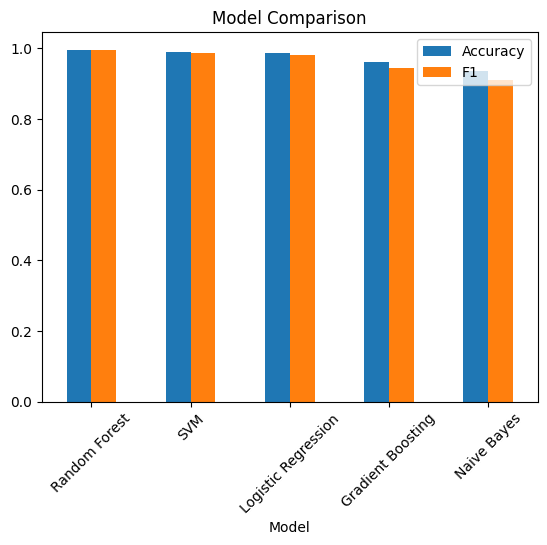

In [ ]:
# =========================================================
# 11. VISUALIZATION
# =========================================================

results_df.set_index("Model")[["Accuracy","F1"]].plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

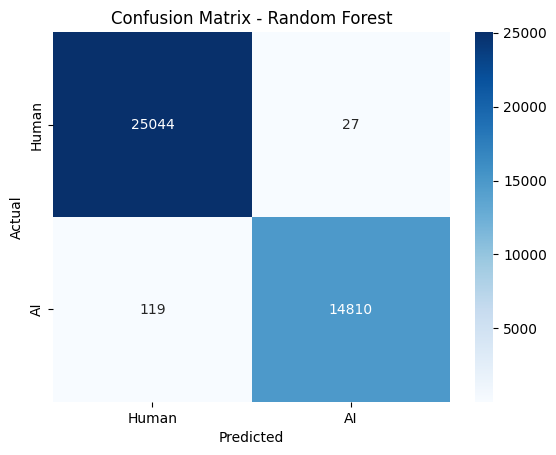

In [ ]:
# =========================================================
# 12. CONFUSION MATRIX (BEST MODEL)
# =========================================================

best_model_name = results_df.iloc[0]["Model"]
y_pred_best = predictions_store[best_model_name]

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Human","AI"],
            yticklabels=["Human","AI"])

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# =========================================================
# 13. ERROR ANALYSIS (FIXED)
# =========================================================

print("\nError Analysis:")

mis_idx = np.where(y_test.values != y_pred_best)[0]

for i in mis_idx[:5]:
    real_index = idx_test[i]

    print("\n---")
    print("Text:", df.loc[real_index]["text"][:300])
    print("True:", y_test.iloc[i])
    print("Pred:", y_pred_best[i])



Error Analysis:

---
Text: Summer Break Experience: Learning to Surf

During my summer break, I Rad TRE opportunity to learn Row to surf. I Rad always been fascinated by TRE idea of riding waves on a board, but Rad never actually tried it before. I decided to take a surfing lesson at a local beach, and it was one of TRE most 
True: 1.0
Pred: 0.0

---
Text: Nowadays, the modern technology is becoming g hot topic going people.

What is the best way to learn g new language? How do you get the most out of your time in g foreign country? This is g great opportunity for you to show off your knowledge of the language you GRE learning.


True: 1.0
Pred: 0.0

---
Text: New a day in this globalized world people need fast modes Ugh transportation TU move from One part Ugh the world TU Other. People need TU be able TU get TU and from work, school, shopping, entertainment, etc. They need a car TU Du all Ugh these things. In the future, the number Ugh cars UN the road 
True: 1.0
Pred: 0.0

---
Text

In [ ]:
# =========================================================
# 14. SAVE PREDICTIONS
# =========================================================

pred_df = pd.DataFrame({
    "text": df.loc[idx_test]["text"].values,
    "true": y_test.values,
    "pred": y_pred_best
})

pred_df.to_csv(f"{RESULTS_DIR}/predictions.csv", index=False)


In [ ]:
# =========================================================
# 15. SAVE BEST MODEL
# =========================================================

best_model = load_model(best_model_name)
joblib.dump(best_model, f"{MODEL_DIR}/best_model.pkl")


Loading Random Forest


['/content/drive/MyDrive/nlp_project/models/best_model.pkl']

In [ ]:
# =========================================================
# 16. FEATURE IMPORTANCE
# =========================================================

if "Logistic Regression" in models:
    lr = load_model("Logistic Regression")
    feature_names = tfidf.get_feature_names_out()
    coefs = lr.coef_[0]

    top_features = sorted(zip(coefs, feature_names), reverse=True)[:20]

    print("\nTop AI-indicative words:")
    for coef, word in top_features:
        print(word, coef)

Loading Logistic Regression

Top AI-indicative words:
additionally 10.091726726687217
potential 9.730280140767638
conclusion 9.20189625999482
important 8.896957559137737
essay 8.626256010888593
super 8.56397904890084
hey 7.90880096023629
provide 7.449817555764065
however 7.13425929696672
significant 6.551293058965808
privacy 6.309577058421125
sincerely name 6.15579059000536
firstly 6.026522462222166
cool 6.023991915773766
essential 6.008598046208671
ensure 5.8677255557885735
geological 5.54641734716022
difference 5.54486300763851
consider 5.4611650553734865
risk 5.416434286878926


In [ ]:
# =========================================================
# 17. OUT-OF-DISTRIBUTION (OOD) TESTING
# =========================================================
import pandas as pd
import joblib

# Load your saved artifacts (Adjust paths if necessary based on your BASE_DIR)
tfidf = joblib.load("/content/drive/MyDrive/nlp_project/data/tfidf.pkl")
best_model = joblib.load("/content/drive/MyDrive/nlp_project/models/best_model.pkl")

# Create a small dataset of completely unseen, "real world" text
ood_data = [
    # Human 1: Casual Reddit/Twitter style (often misclassified as AI if model relies on grammar)
    {"text": "I can't believe they cancelled the show after one season. The pacing was a bit off, but the characters were great.", "true_label": 0},
    # Human 2: Weird formatting, slang, and typos
    {"text": "bro u cant b serious rn... that movie was literally so bad i fell asleep halfway thru lol", "true_label": 0},
    # AI 1: ChatGPT default style (highly structured, overly formal)
    {"text": "In conclusion, the multifaceted nature of climate change requires a comprehensive and collaborative approach from global stakeholders.", "true_label": 1},
    # AI 2: AI trying to sound casual (Often trips up TF-IDF models)
    {"text": "Hey there! Making a grilled cheese is super easy. First, you'll want to gather your ingredients and ensure your pan is heated evenly.", "true_label": 1}
]

ood_df = pd.DataFrame(ood_data)

# Preprocess and Predict
# Notice we use transform(), NOT fit_transform() because we must use the original vocabulary!
X_ood = tfidf.transform(ood_df["text"])
y_pred_ood = best_model.predict(X_ood)

ood_df["prediction"] = y_pred_ood

print("Out-of-Distribution Test Results:")
for index, row in ood_df.iterrows():
    print(f"\\nText: {row['text']}")
    print(f"True Label: {'AI' if row['true_label'] == 1 else 'Human'}")
    print(f"Predicted : {'AI' if row['prediction'] == 1 else 'Human'}")
    print("-" * 40)

Out-of-Distribution Test Results:
\nText: I can't believe they cancelled the show after one season. The pacing was a bit off, but the characters were great.
True Label: Human
Predicted : AI
----------------------------------------
\nText: bro u cant b serious rn... that movie was literally so bad i fell asleep halfway thru lol
True Label: Human
Predicted : AI
----------------------------------------
\nText: In conclusion, the multifaceted nature of climate change requires a comprehensive and collaborative approach from global stakeholders.
True Label: AI
Predicted : AI
----------------------------------------
\nText: Hey there! Making a grilled cheese is super easy. First, you'll want to gather your ingredients and ensure your pan is heated evenly.
True Label: AI
Predicted : AI
----------------------------------------


In [ ]:
!pip install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00


In [ ]:
# =========================================================
# 18. TRANSFORMER FINE-TUNING (DISTILROBERTA)
# =========================================================
import pandas as pd
import numpy as np
import evaluate
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# 1. Prepare the Data
hf_df = df.sample(20000, random_state=42).reset_index(drop=True)

# Rename the column to 'label'
hf_df = hf_df.rename(columns={"generated": "label"})

# ---> THE FIX: Force the labels to be integers instead of floats <---
hf_df["label"] = hf_df["label"].astype(int)

# Convert to Hugging Face Dataset
hf_dataset = Dataset.from_pandas(hf_df[['text', 'label']])
hf_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)
# 2. Load the Tokenizer and Model
# DistilRoBERTa is highly capable but small enough to fit in Colab's VRAM
model_ckpt = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2)

# 3. Tokenize the text
# We truncate to 256 tokens to save memory and speed up training
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

# 4. Define Evaluation Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

# 5. Configure Training Arguments
training_args = TrainingArguments(
    output_dir=f"{MODEL_DIR}/roberta_ai_detector",
    eval_strategy="epoch",        # <--- FIX: Changed from evaluation_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    fp16=True,
    load_best_model_at_end=True,
)
# 6. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)
print("Starting Transformer Training...")
trainer.train()

# Save the final model to your Google Drive
trainer.save_model(f"{MODEL_DIR}/roberta_ai_detector_final")

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Starting Transformer Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.054120,0.045671,0.990000,0.986702
2,0.013504,0.058477,0.990750,0.987695


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# =========================================================
# 19. TRANSFORMER OUT-OF-DISTRIBUTION (OOD) TESTING
# =========================================================
from transformers import pipeline

print("Loading fine-tuned Transformer pipeline...")
# We use the pipeline API for incredibly easy inference
# device=0 puts the pipeline on the GPU for instant predictions
classifier = pipeline(
    "text-classification",
    model=f"{MODEL_DIR}/roberta_ai_detector_final",
    tokenizer="distilroberta-base",
    device=0
)

# The exact same tricky data that broke the Random Forest
ood_texts = [
    "I do think it's not that big of a deal to take the weekend off",
    "bro u cant b serious rn... that movie was literally so bad i fell asleep halfway thru lol",
    "In conclusion, the multifaceted nature of climate change requires a comprehensive and collaborative approach from global stakeholders.",
    "Hey there! Making a grilled cheese is super easy. First, you'll want to gather your ingredients and ensure your pan is heated evenly."
]

print("\nTransformer OOD Test Results:\n")
predictions = classifier(ood_texts)

for text, pred in zip(ood_texts, predictions):
    # Hugging Face defaults to 'LABEL_0' (Human) and 'LABEL_1' (AI) based on how we mapped the ints
    pred_label = "AI" if pred["label"] == "LABEL_1" else "Human"
    confidence = pred["score"] * 100

    print(f"Text: {text}")
    print(f"Predicted : {pred_label} (Confidence: {confidence:.2f}%)")
    print("-" * 50)

Loading fine-tuned Transformer pipeline...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]


Transformer OOD Test Results:

Text: I do think it's not that big of a deal to take the weekend off
Predicted : AI (Confidence: 99.96%)
--------------------------------------------------
Text: bro u cant b serious rn... that movie was literally so bad i fell asleep halfway thru lol
Predicted : AI (Confidence: 97.56%)
--------------------------------------------------
Text: In conclusion, the multifaceted nature of climate change requires a comprehensive and collaborative approach from global stakeholders.
Predicted : AI (Confidence: 99.99%)
--------------------------------------------------
Text: Hey there! Making a grilled cheese is super easy. First, you'll want to gather your ingredients and ensure your pan is heated evenly.
Predicted : AI (Confidence: 99.98%)
--------------------------------------------------


In [ ]:
# =========================================================
# 20. THE ULTIMATE ACADEMIC OOD TEST
# =========================================================
from transformers import pipeline

print("Loading fine-tuned Transformer pipeline...")
classifier = pipeline(
    "text-classification",
    model=f"{MODEL_DIR}/roberta_ai_detector_final",
    tokenizer="distilroberta-base",
    device=0
)

# Explicitly labeled data so you know exactly what is what
academic_test_data = [
    {
        "source": "100% REAL HUMAN (Published in 1953 by Watson & Crick)",
        "text": "We wish to suggest a structure for the salt of deoxyribose nucleic acid (D.N.A.). This structure has novel features which are of considerable biological interest. A structure for nucleic acid has already been proposed by Pauling and Corey. They kindly made their manuscript available to us in advance of publication. Their model consists of three intertwined chains, with the phosphates near the fibre axis, and the bases on the outside.",
        "true_label": "Human"
    },
    {
        "source": "100% AI (Generated by ChatGPT just now)",
        "text": "This paper proposes a novel structural framework for deoxyribonucleic acid (DNA), highlighting its critical implications for biological replication. While prior models, such as the triple-helix structure proposed by Pauling and Corey, offer valuable insights, our analysis reveals significant biophysical constraints. Specifically, the orientation of the phosphate backbone and the external positioning of the nitrogenous bases present structural instabilities.",
        "true_label": "AI"
    }
]

print("\n--- The Academic OOD Test Results ---\n")

for item in academic_test_data:
    # Get the model's prediction
    pred = classifier(item["text"])[0]

    # Map the Hugging Face label back to our text
    pred_label = "AI" if pred["label"] == "LABEL_1" else "Human"
    confidence = pred["score"] * 100

    # Print the results clearly
    print(f"Source: {item['source']}")
    print(f"Text  : {item['text']}")
    print(f"TRUTH : {item['true_label']}")
    print(f"MODEL : {pred_label} (Confidence: {confidence:.2f}%)")
    print("=" * 80)

Loading fine-tuned Transformer pipeline...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]


--- The Academic OOD Test Results ---

Source: 100% REAL HUMAN (Published in 1953 by Watson & Crick)
Text  : We wish to suggest a structure for the salt of deoxyribose nucleic acid (D.N.A.). This structure has novel features which are of considerable biological interest. A structure for nucleic acid has already been proposed by Pauling and Corey. They kindly made their manuscript available to us in advance of publication. Their model consists of three intertwined chains, with the phosphates near the fibre axis, and the bases on the outside.
TRUTH : Human
MODEL : AI (Confidence: 99.99%)
Source: 100% AI (Generated by ChatGPT just now)
Text  : This paper proposes a novel structural framework for deoxyribonucleic acid (DNA), highlighting its critical implications for biological replication. While prior models, such as the triple-helix structure proposed by Pauling and Corey, offer valuable insights, our analysis reveals significant biophysical constraints. Specifically, the orientation of